# KNN Tuning

| | |
|---|---|
| **Algorithm** | K-Nearest Neighbors |
| **Dataset** | Diabetes (Pima Indians), 768 → 2,000 (augmented) |
| **Task** | Binary Classification (당뇨 여부) |
| **Metric** | CV Accuracy, CV F1 — 5-fold StratifiedKFold |

## 튜닝 포인트

| # | 튜닝 | 내용 | 기대 효과 |
|---|---|---|---|
| 0 | Data Augmentation | Gaussian noise로 합성 샘플 생성 | 샘플 부족으로 인한 CV 분산 감소 |
| 1 | Feature Scaling | StandardScaler | 거리 계산 시 feature 스케일 왜곡 제거 |
| 2 | GridSearchCV + Pipeline | n_neighbors / metric 탐색 | 최적 파라미터 탐색 + 데이터 누수 방지 |

---
## 1. 환경 설정

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

---
## 2. 데이터 로딩

In [93]:
df_orig = pd.read_csv('../datasets/diabetes.csv')
print(f'Shape : {df_orig.shape}')
print(f'\n클래스 분포:')
print(df_orig['Outcome'].value_counts())
print(f'\n결측치:')
print(df_orig.isnull().sum())
df_orig.describe()

Shape : (768, 9)

클래스 분포:
Outcome
0    500
1    268
Name: count, dtype: int64

결측치:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Tuning 0: Data Augmentation
---
- KNN은 거리 기반이라 샘플이 부족하면 결정경계 주변 이웃이 적어 분류가 불안정해진다.
- 기존 샘플에 각 feature std의 10%에 해당하는 Gaussian noise를 더해 합성 샘플을 생성한다.
- 클래스 비율은 원본(500:268)과 동일하게 유지한다.
- 실제 프로젝트에서는 SMOTE나 실데이터 추가 수집이 더 바람직하다.

Before: 768  ->  After: 2000
Class distribution: {0: 1302, 1: 698}


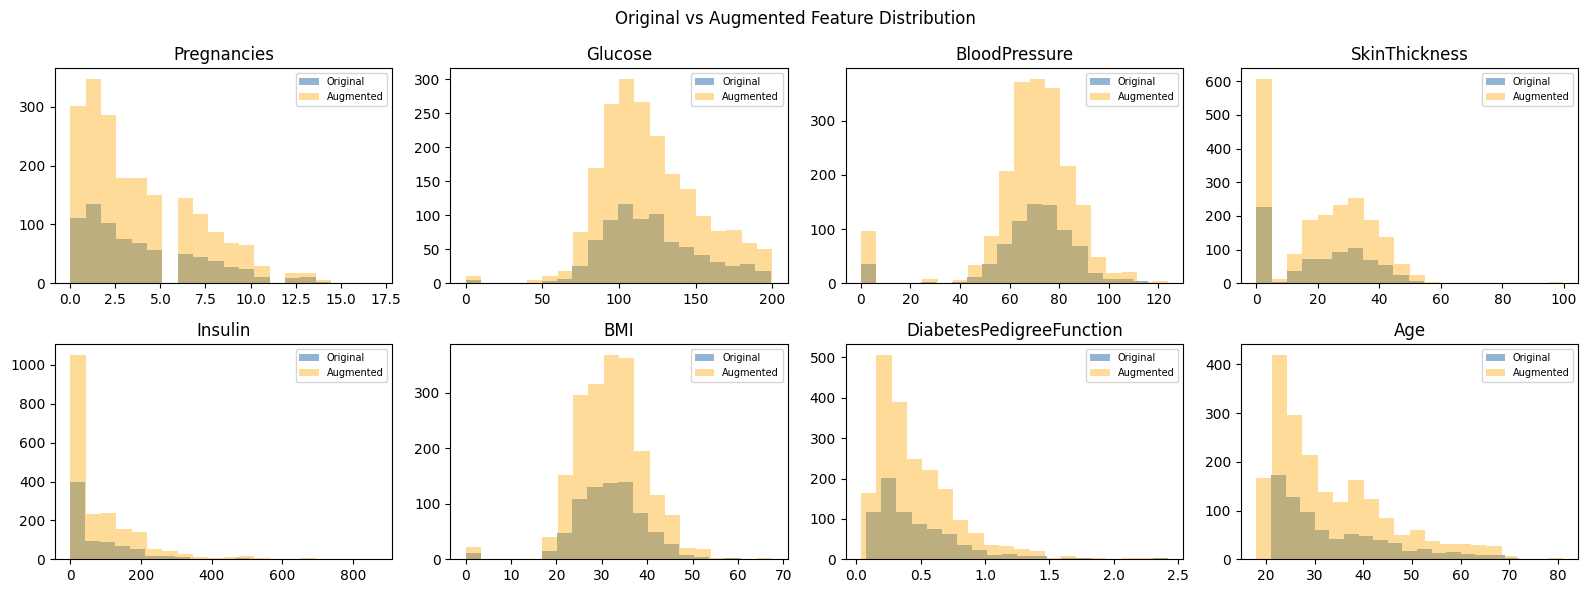

In [94]:
np.random.seed(42)

feature_cols = df_orig.drop(columns='Outcome').columns.tolist()
TARGET_SIZE  = 2000
n_to_add     = TARGET_SIZE - len(df_orig)

def augment_class(df_class, n, noise_scale=0.1):
    stds = df_class[feature_cols].std().values
    idx  = np.random.choice(len(df_class), size=n, replace=True)
    base = df_class[feature_cols].iloc[idx].values
    return base + np.random.randn(*base.shape) * (stds * noise_scale)

ratio_0 = len(df_orig[df_orig['Outcome'] == 0]) / len(df_orig)
n_add_0 = round(n_to_add * ratio_0)
n_add_1 = n_to_add - n_add_0

df0 = df_orig[df_orig['Outcome'] == 0].reset_index(drop=True)
df1 = df_orig[df_orig['Outcome'] == 1].reset_index(drop=True)

syn0 = augment_class(df0, n_add_0)
syn1 = augment_class(df1, n_add_1)

int_idx = [feature_cols.index(c) for c in ['Pregnancies', 'Age']]
for arr in [syn0, syn1]:
    arr[:, int_idx] = np.round(np.clip(arr[:, int_idx], 0, None))
    for j in range(arr.shape[1]):
        if j not in int_idx:
            arr[:, j] = np.clip(arr[:, j], 0, None)

df_syn0 = pd.DataFrame(syn0, columns=feature_cols).assign(Outcome=0)
df_syn1 = pd.DataFrame(syn1, columns=feature_cols).assign(Outcome=1)

df_aug = pd.concat([df_orig, df_syn0, df_syn1], ignore_index=True)\
           .sample(frac=1, random_state=42).reset_index(drop=True)
df_aug['Pregnancies'] = df_aug['Pregnancies'].round().astype(int)
df_aug['Age']         = df_aug['Age'].round().astype(int)

print(f'Before: {df_orig.shape[0]}  ->  After: {df_aug.shape[0]}')
print(f'Class distribution: {df_aug["Outcome"].value_counts().to_dict()}')

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, feature_cols):
    ax.hist(df_orig[col], bins=20, alpha=0.6, label='Original', color='steelblue')
    ax.hist(df_aug[col],  bins=20, alpha=0.4, label='Augmented', color='orange')
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.suptitle('Original vs Augmented Feature Distribution')
plt.tight_layout()
plt.show()

In [95]:
X = df_aug.drop(columns='Outcome').values
y = df_aug['Outcome'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

**5-fold StratifiedKFold CV**
- train/test를 하나로 고정하면 어떤 split이냐에 따라 점수가 달라진다.
- 전체 데이터를 5등분해서 각 조각이 한 번씩 test를 맡고, 5번 평균을 최종 점수로 사용한다.
- Stratified: 각 fold에서 클래스 비율을 원본(65:35)과 동일하게 유지한다.

|        | 구간 1 | 구간 2 | 구간 3 | 구간 4 | 구간 5 | 점수    |
|--------|--------|--------|--------|--------|--------|---------|
| Fold 1 | TEST   | train  | train  | train  | train  | score 1 |
| Fold 2 | train  | TEST   | train  | train  | train  | score 2 |
| Fold 3 | train  | train  | TEST   | train  | train  | score 3 |
| Fold 4 | train  | train  | train  | TEST   | train  | score 4 |
| Fold 5 | train  | train  | train  | train  | TEST   | score 5 |

## Base Model
---
- 튜닝 전 기준점 (baseline)
- 스케일링 없음, n_neighbors=12 고정

In [96]:
base_acc = cross_val_score(KNeighborsClassifier(n_neighbors=12), X, y, cv=cv, scoring='accuracy').mean()
base_f1  = cross_val_score(KNeighborsClassifier(n_neighbors=12), X, y, cv=cv, scoring='f1').mean()
print(f'Base — CV Accuracy: {base_acc:.4f}  CV F1: {base_f1:.4f}')

Base — CV Accuracy: 0.7860  CV F1: 0.6540


## Tuning 1: Feature Scaling
---
- KNN은 유클리드 거리로 이웃을 판단하므로, feature 스케일이 다르면 값이 큰 feature가 거리를 지배한다.
  - e.g. Glucose (0~200) vs DiabetesPedigreeFunction (0~2.4)
- StandardScaler는 각 feature를 평균=0, 분산=1로 변환해 모든 feature가 균등하게 거리에 기여하도록 한다.

**데이터 누수 주의**
- `scaler.fit()`은 train data에만 적용해야 한다. test data에 fit하면 test 분포 정보가 학습에 개입된다.
- Pipeline으로 묶으면 CV 각 fold 내에서 fit이 일어나므로 구조적으로 방지된다.

In [97]:
scaled_pl = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=12))
])

scaled_acc = cross_val_score(scaled_pl, X, y, cv=cv, scoring='accuracy').mean()
scaled_f1  = cross_val_score(scaled_pl, X, y, cv=cv, scoring='f1').mean()
print(f'Scaled — CV Accuracy: {scaled_acc:.4f}  CV F1: {scaled_f1:.4f}')

Scaled — CV Accuracy: 0.7990  CV F1: 0.6767


## Tuning 2: GridSearchCV + Pipeline
---
- param_grid의 모든 조합에 대해 5-fold CV를 수행하고, CV accuracy가 가장 높은 파라미터를 선택한다.
- X_train이 아닌 전체 X로 탐색해야 X_train 편향 없이 일반화된 최적 파라미터를 찾을 수 있다.

| 파라미터 | 역할 | 탐색 범위 |
|---|---|---|
| `n_neighbors` | 이웃 수 — 작을수록 복잡한 경계(과적합), 클수록 단순(과소적합) | 3 ~ 20 |
| `metric` | euclidean(L2)은 이상치에 민감, manhattan(L1)은 강건 | euclidean, manhattan |

In [98]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(3, 21),
    'knn__metric':      ['euclidean', 'manhattan']
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X, y)

print(f'Best params : {grid.best_params_}')
print(f'Best CV Acc : {grid.best_score_:.4f}')

grid_acc = grid.best_score_
grid_f1  = cross_val_score(grid.best_estimator_, X, y, cv=cv, scoring='f1').mean()

Best params : {'knn__metric': 'euclidean', 'knn__n_neighbors': 3}
Best CV Acc : 0.8825


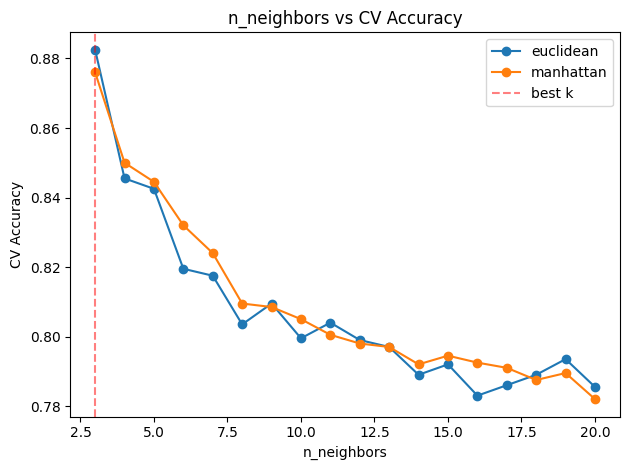

In [99]:
# n_neighbors별 CV accuracy 시각화
cv_results = pd.DataFrame(grid.cv_results_)
cv_results['n_neighbors'] = cv_results['params'].apply(lambda p: p['knn__n_neighbors'])
cv_results['metric']      = cv_results['params'].apply(lambda p: p['knn__metric'])

for metric, grp in cv_results.groupby('metric'):
    plt.plot(grp['n_neighbors'], grp['mean_test_score'], marker='o', label=metric)
plt.axvline(grid.best_params_['knn__n_neighbors'], color='red', linestyle='--', alpha=0.5, label='best k')
plt.xlabel('n_neighbors')
plt.ylabel('CV Accuracy')
plt.title('n_neighbors vs CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## 결과 비교
---
- 모든 모델을 동일한 5-fold StratifiedKFold CV로 평가

                  Model  CV Accuracy    CV F1 Acc Delta F1 Delta
Base (no scaling, k=12)       0.7860 0.653968   +0.0000  +0.0000
Tuning 1: Scaled (k=12)       0.7990 0.676718   +0.0130  +0.0227
 Tuning 2: GridSearchCV       0.8825 0.826452   +0.0965  +0.1725


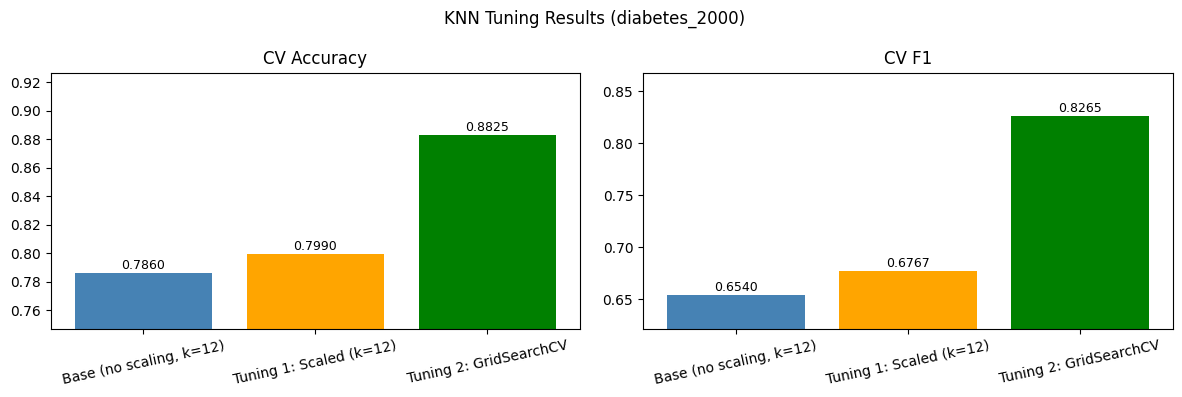

In [100]:
results = pd.DataFrame({
    'Model':       ['Base (no scaling, k=12)', 'Tuning 1: Scaled (k=12)', 'Tuning 2: GridSearchCV'],
    'CV Accuracy': [base_acc,  scaled_acc,  grid_acc],
    'CV F1':       [base_f1,   scaled_f1,   grid_f1]
})

results['Acc Delta'] = (results['CV Accuracy'] - base_acc).map(lambda x: f'{x:+.4f}')
results['F1 Delta']  = (results['CV F1']       - base_f1 ).map(lambda x: f'{x:+.4f}')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'orange', 'green']
for ax, col in zip(axes, ['CV Accuracy', 'CV F1']):
    bars = ax.bar(results['Model'], results[col], color=colors)
    ax.set_ylim(results[col].min() * 0.95, results[col].max() * 1.05)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=12)
    for bar, val in zip(bars, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('KNN Tuning Results (diabetes_2000)')
plt.tight_layout()
plt.show()

In [101]:
# 최종 모델 상세 리포트
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
grid_final = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_final.fit(X_train, y_train)
print('[ 최종 모델 Classification Report ]')
print(classification_report(y_test, grid_final.predict(X_test), target_names=['No Diabetes', 'Diabetes']))

[ 최종 모델 Classification Report ]
              precision    recall  f1-score   support

 No Diabetes       0.91      0.93      0.92       260
    Diabetes       0.86      0.82      0.84       140

    accuracy                           0.89       400
   macro avg       0.89      0.88      0.88       400
weighted avg       0.89      0.89      0.89       400

